# Tutorial: Extracting Donor Embeddings with PULSAR and Predicting Lupus Disease Status

This tutorial demonstrates how to:
1. Load a pre-trained PULSAR model
2. Extract zero-shot donor-level embeddings from single-cell data
3. Perform binary classification to distinguish lupus patients from healthy controls using donor embeddings with proper train-test split

## Overview

PULSAR is a model that aggregates single-cell embeddings to create donor-level representations. These donor embeddings can be used for various downstream tasks, including predicting donor-level phenotypes such as disease status. In this example, we will use PULSAR embeddings to predict whether a donor has **systemic lupus erythematosus (SLE)** or is a healthy control, based on their single-cell gene expression profiles. We will use a lupus dataset from [Perez et al.](https://www.science.org/doi/10.1126/science.abf1970) for this demonstration.

Example data used in this tutorial can be downloaded from [here](https://drive.google.com/file/d/1ln3d5Nd0hkMSMfVR_bLaRKCrU3yikEVd/view?usp=sharing).

## 1. Setup and Imports

First, let's import the necessary libraries and set up autoreload for development.

In [1]:
import scanpy as sc
import numpy as np
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

from pulsar.utils import extract_donor_embeddings_from_h5ad
from pulsar.model import PULSAR

%load_ext autoreload
%autoreload 2

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)
""

/lfs/blackwell1/0/kuanpang/pulsar-dev/PULSAR-release-dev/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


''

## 2. Load Single-Cell Data

We'll use a lupus dataset, which contains single-cell RNA-seq data from PBMC samples of both **lupus patients** and **healthy controls**. The dataset includes disease status annotations for each donor. The h5ad file has been preprocessed and includes UCE (Universal Cell Embeddings) in the `obsm` field, which capture the transcriptional state of individual cells.

Example data used in this tutorial can be downloaded from [here](https://drive.google.com/file/d/1ln3d5Nd0hkMSMfVR_bLaRKCrU3yikEVd/view?usp=sharing).

In [2]:
# Load the h5ad file containing single-cell data + UCE embeddings
data_path = "/lfs/blackwell1/0/kuanpang/pulsar-dev/PULSAR-release-dev/benchmark_data/lupus_subsampled_uce_adata.h5ad"
adata = sc.read_h5ad(data_path)

print(f"Dataset shape: {adata.shape}")
print(f"Number of unique donors: {adata.obs['donor_id'].nunique()}")

Dataset shape: (315919, 1902)
Number of unique donors: 261


In [3]:
# Examine the data structure
adata

AnnData object with n_obs × n_vars = 315919 × 1902
    obs: 'library_uuid', 'assay_ontology_term_id', 'mapped_reference_annotation', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'cell_state', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_state', 'suspension_enriched_cell_types', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'organism_ontology_term_id', 'disease_ontology_term_id', 'sex_ontology_term_id', 'Processing_Cohort', 'ct_cov', 'ind_cov', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'citation', 'default_embedding', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_uce'

## 3. Load Pre-trained PULSAR Model

Load the pre-trained PULSAR model from 🤗HuggingFace and prepare it for inference. We use the `pulsar-pbmc` model, which was trained on PBMC data and is well-suited for analyzing immune cell populations relevant to lupus.



In [4]:
# Load the model from the huggingface model hub
pulsar_model = PULSAR.from_pretrained("KuanP/pulsar-pbmc")


# Set model to evaluation mode and move to GPU
pulsar_model.eval()
pulsar_model.cuda()

# Convert to bfloat16 for efficiency
pulsar_model = pulsar_model.to(torch.bfloat16)

print("Model loaded successfully!")

Model loaded successfully!


## 4. Extract Donor Embeddings

Use the PULSAR model to extract donor-level embeddings from the single-cell data. Each donor's embedding is computed by aggregating information from all cells belonging to that donor, capturing the overall immune cell composition and state that may be indicative of lupus. The `donor_id` column in `adata.obs` is used to identify cells from the same donor. `sample_cell_num` specifies the number of cells to sample per donor for embedding extraction (1024 cells provides a good representation of each donor's immune profile).

In [5]:
# Extract donor embeddings
donor_embedding_collection = extract_donor_embeddings_from_h5ad(
    adata,
    donor_id_key="donor_id",
    model=pulsar_model,
    sample_cell_num=1024
)

print(f"Extracted embeddings for {len(donor_embedding_collection)} donors")
# Show example of embedding structure
first_donor_id = list(donor_embedding_collection.keys())[0]
print(f"\nExample donor ID: {first_donor_id}")
print(f"Embedding shape: {donor_embedding_collection[first_donor_id]['embedding'][0].shape}")

Resample 0 time


0it [00:00, ?it/s]

27it [00:00, 27.26it/s]

Extracted embeddings for 261 donors

Example donor ID: 1404
Embedding shape: (512,)


## 5. Prepare Data for Lupus Classification

Create a mapping between donor IDs and their disease status (lupus vs. healthy control), then prepare the feature matrix (X) and target vector (y). We'll examine the class distribution to understand the balance between lupus patients and healthy controls in our dataset.

In [6]:
# Get disease to age mapping
donor_id_to_disease = adata.obs.groupby("donor_id", observed=True)["disease"].first().to_dict()

print(f"Number of donors with disease information: {len(donor_id_to_disease)}")


Number of donors with disease information: 261


In [7]:
# Prepare feature matrix (X) and target vector (y)
X = []
y = []
donor_ids = []

for donor_id, donor_data in donor_embedding_collection.items():
    embedding = donor_data["embedding"][0]  # Get the first embedding
    X.append(embedding)
    y.append(donor_id_to_disease[donor_id])
    donor_ids.append(donor_id)

X = np.vstack(X)
y = np.array(y)
donor_ids = np.array(donor_ids)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nDisease distribution:")
unique, counts = np.unique(y, return_counts=True)
for disease, count in zip(unique, counts):
    print(f"  {disease}: {count} donors ({count/len(y)*100:.1f}%)")

Feature matrix shape: (261, 512)
Target vector shape: (261,)

Disease distribution:
  normal: 99 donors (37.9%)
  systemic lupus erythematosus: 162 donors (62.1%)


## 6. Train-Test Split for Lupus Classification

To properly evaluate the model's ability to distinguish lupus patients from healthy controls, we'll split the donors into training and test sets. This ensures we're evaluating on held-out donors that the model hasn't seen during training. We use stratified splitting to maintain the proportion of lupus vs. healthy donors in both sets.

In [8]:
# Split data into train and test sets (80-20 split) with stratification
X_train, X_test, y_train, y_test, donors_train, donors_test = train_test_split(
    X, y, donor_ids, test_size=0.2, random_state=0, stratify=y
)

print(f"Training set size: {len(X_train)} donors")
print(f"Test set size: {len(X_test)} donors")
print(f"\nTraining set disease distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for disease, count in zip(unique, counts):
    print(f"  {disease}: {count} donors ({count/len(y_train)*100:.1f}%)")
print(f"\nTest set disease distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for disease, count in zip(unique, counts):
    print(f"  {disease}: {count} donors ({count/len(y_test)*100:.1f}%)")

Training set size: 208 donors
Test set size: 53 donors

Training set disease distribution:
  normal: 79 donors (38.0%)
  systemic lupus erythematosus: 129 donors (62.0%)

Test set disease distribution:
  normal: 20 donors (37.7%)
  systemic lupus erythematosus: 33 donors (62.3%)


## 7. Train Logistic Regression Model

Train a logistic regression model to predict lupus disease status from donor embeddings using only the training data. We use `class_weight='balanced'` to account for any potential imbalance between lupus patients and healthy controls.

In [9]:
# Train logistic regression model on training data
clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

print("Logistic regression model trained successfully!")

Logistic regression model trained successfully!


## 8. Evaluate Model Performance

Evaluate the model on both training and test sets to check for overfitting and assess how well the PULSAR embeddings can distinguish lupus patients from healthy controls. We report multiple classification metrics including accuracy, precision, recall, and F1-score.

In [10]:
# Make predictions
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

# Calculate metrics for training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_recall = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

# Calculate metrics for test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

# Print results
print("=" * 60)
print("TRAINING SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy: {train_accuracy:.4f}")
print(f"Precision (weighted): {train_precision:.4f}")
print(f"Recall (weighted): {train_recall:.4f}")
print(f"F1-score (weighted): {train_f1:.4f}")

print("\n" + "=" * 60)
print("TEST SET PERFORMANCE (Held-out Donors)")
print("=" * 60)
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision (weighted): {test_precision:.4f}")
print(f"Recall (weighted): {test_recall:.4f}")
print(f"F1-score (weighted): {test_f1:.4f}")

print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("=" * 60)
print(classification_report(y_test, y_test_pred, zero_division=0))

TRAINING SET PERFORMANCE
Accuracy: 0.9663
Precision (weighted): 0.9679
Recall (weighted): 0.9663
F1-score (weighted): 0.9665

TEST SET PERFORMANCE (Held-out Donors)
Accuracy: 0.9434
Precision (weighted): 0.9446
Recall (weighted): 0.9434
F1-score (weighted): 0.9437

DETAILED CLASSIFICATION REPORT (Test Set)
                              precision    recall  f1-score   support

                      normal       0.90      0.95      0.93        20
systemic lupus erythematosus       0.97      0.94      0.95        33

                    accuracy                           0.94        53
                   macro avg       0.94      0.94      0.94        53
                weighted avg       0.94      0.94      0.94        53



## 9. Visualize Results

Create confusion matrices to visualize the classification performance for both training and test sets. The confusion matrix shows how well the model can correctly identify lupus patients vs. healthy controls, including any misclassifications.

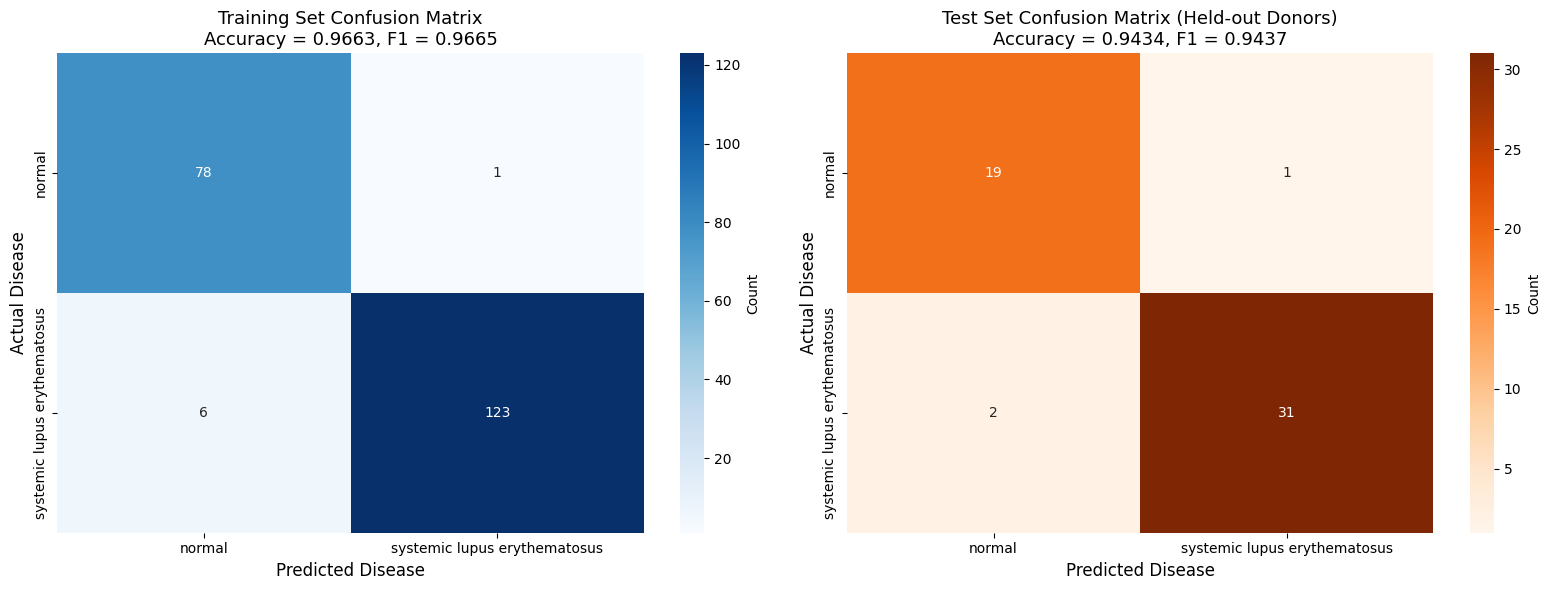

In [11]:
# Create confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

# Get unique class labels
class_labels = sorted(np.unique(y))

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set confusion matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Disease', fontsize=12)
axes[0].set_ylabel('Actual Disease', fontsize=12)
axes[0].set_title(f'Training Set Confusion Matrix\nAccuracy = {train_accuracy:.4f}, F1 = {train_f1:.4f}', 
                  fontsize=13)

# Test set confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_xlabel('Predicted Disease', fontsize=12)
axes[1].set_ylabel('Actual Disease', fontsize=12)
axes[1].set_title(f'Test Set Confusion Matrix (Held-out Donors)\nAccuracy = {test_accuracy:.4f}, F1 = {test_f1:.4f}', 
                  fontsize=13)

plt.tight_layout()
plt.show()